In [1]:
import MCtools
DBdir = "/sps/planck/Users/tristram/Soft/Hillik/chains"
clth = read_cl( "/sps/planck/Users/tristram/Models/planck_base_planck_2018_TTTEEElowllowE.fits")
lth = arange(len(clth[0]))

## Models

### Planck

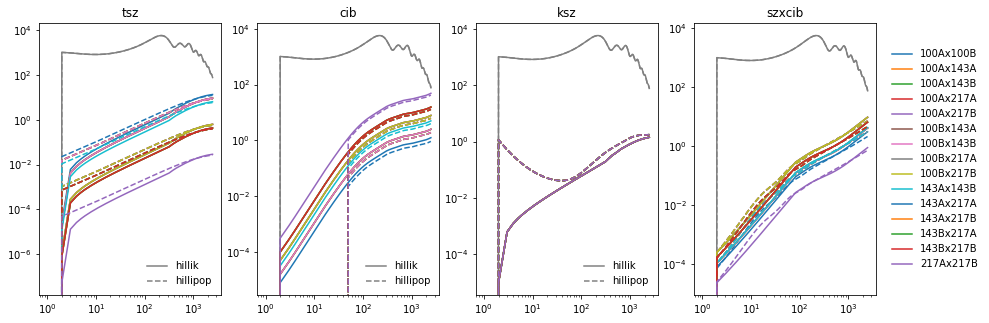

In [2]:
import itertools
xfreq = list(itertools.combinations( ['100A','100B','143A','143B','217A','217B'],2))

fg_list = ["dust","tsz","ksz","cib","szxcib","ps"]
hlk = dict( zip(fg_list, np.load( f"{DBdir}/../hillik_plk_fgs.npy")))
fg_list = ["dust","tsz","ksz","cib","szxcib","ps_radio","ps_dusty","ps"]
hlp = dict( zip(fg_list,np.load( f"{DBdir}/../hillipop_fgs.npy")))

figure( figsize=(15,5))
for i_f,fgname in enumerate(["tsz","cib","ksz","szxcib"]):
    subplot(1,4,i_f+1)
    plot( lth*(lth+1)/2/pi*clth[0]*1e12, color='grey')
    plot( lth*(lth+1)/2/pi*clth[0]*1e12, '--', color='grey')
    legend( ['hillik','hillipop'])
    for c in range(len(xfreq)):
        p1=plot( abs(hlk[fgname][c]), label="%sx%s" % xfreq[c])
        p2=plot( abs(hlp[fgname][c]), '--', color=p1[0].get_color())
    title(fgname)
    if i_f==3: legend( bbox_to_anchor=(1.04,0.5), loc="center left")
    loglog()

### SPT

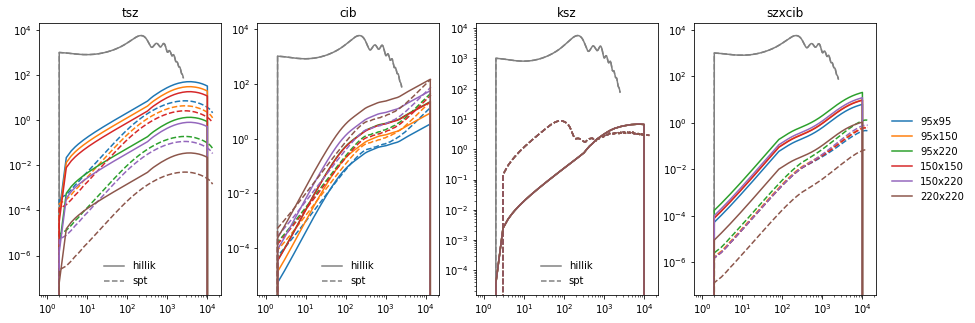

In [3]:
xfreq = ["95x95","95x150","95x220","150x150","150x220","220x220"]

fg_list = ["dust","tsz","ksz","cib","szxcib","ps"]
hlk = dict( zip(fg_list, np.load( f"{DBdir}/../hillik_spt_fgs.npy")))
fg_list = ["ps_dg","cib","ps_rg","tsz","ksz","dust","szxcib","szxradio"]
spt = dict( zip(fg_list,np.load( f"{DBdir}/../spt_fgs.npy")))

figure( figsize=(15,5))
for i_f,fgname in enumerate(["tsz","cib","ksz","szxcib"]):
    subplot(1,4,i_f+1)
    plot( lth*(lth+1)/2/pi*clth[0]*1e12, color='grey')
    plot( lth*(lth+1)/2/pi*clth[0]*1e12, '--', color='grey')
    legend( ['hillik','spt'])
    for c in range(len(xfreq)):
        p1=plot( abs(hlk[fgname][c]), label=f"{xfreq[c]}")
        p2=plot( abs(spt[fgname][c]), '--', color=p1[0].get_color())
    title(fgname)
    if i_f==3: legend( bbox_to_anchor=(1.04,0.5), loc="center left")
    loglog()

### ACT (deep)

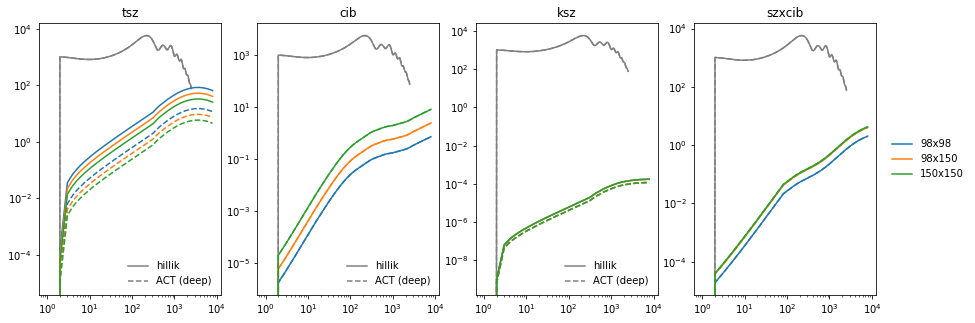

In [4]:
xfreq = ["98x98","98x150","150x150"]

fg_list = ["dust","tsz","ksz","cib","szxcib","ps"]
hlk = dict( zip(fg_list, np.load( f"{DBdir}/../hillik_ACTd_fgs_tt.npy")))
fg_list = ["cib","ps_dg","ps_rg","dust","tsz","ksz","szxcib"]
act = dict( zip(fg_list,np.load( f"{DBdir}/../act_deep_fgs_tt.npy")))
act['ps'] = act['ps_dg']+act['ps_rg']

figure( figsize=(15,5))
for i_f,fgname in enumerate(["tsz","cib","ksz","szxcib"]):
    subplot(1,4,i_f+1)
    plot( lth*(lth+1)/2/pi*clth[0]*1e12, color='grey')
    plot( lth*(lth+1)/2/pi*clth[0]*1e12, '--', color='grey')
    legend( ['hillik','ACT (deep)'])
    for c in range(len(xfreq)):
        p1=plot( abs(hlk[fgname][c]), label=f"{xfreq[c]}")
        p2=plot( abs(act[fgname][c]), '--', color=p1[0].get_color())
    title(fgname)
    if i_f==3: legend( bbox_to_anchor=(1.04,0.5), loc="center left")
    loglog()

### ACT (wide)

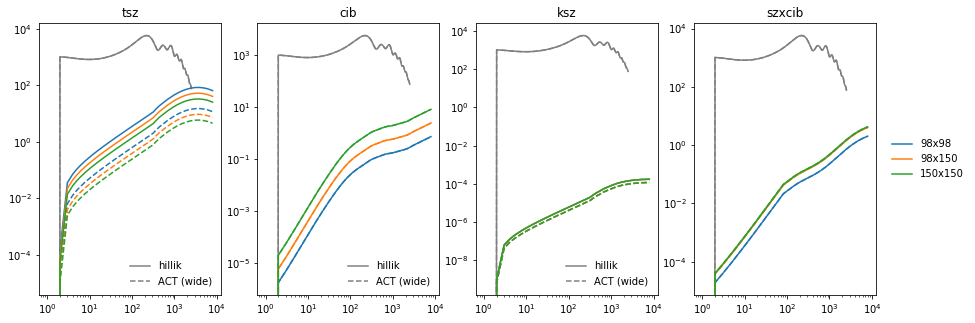

In [5]:
xfreq = ["98x98","98x150","150x150"]

fg_list = ["dust","tsz","ksz","cib","szxcib","ps"]
hlk = dict( zip(fg_list, np.load( f"{DBdir}/../hillik_ACTw_fgs_tt.npy")))
fg_list = ["cib","ps_dg","ps_rg","dust","tsz","ksz","szxcib"]
act = dict( zip(fg_list,np.load( f"{DBdir}/../act_wide_fgs_tt.npy")))
act['ps'] = act['ps_dg']+act['ps_rg']

figure( figsize=(15,5))
for i_f,fgname in enumerate(["tsz","cib","ksz","szxcib"]):
    subplot(1,4,i_f+1)
    plot( lth*(lth+1)/2/pi*clth[0]*1e12, color='grey')
    plot( lth*(lth+1)/2/pi*clth[0]*1e12, '--', color='grey')
    legend( ['hillik','ACT (wide)'])
    for c in range(len(xfreq)):
        p1=plot( abs(hlk[fgname][c]), label=f"{xfreq[c]}")
        p2=plot( abs(act[fgname][c]), '--', color=p1[0].get_color())
    title(fgname)
    if i_f==3: legend( bbox_to_anchor=(1.04,0.5), loc="center left")
    loglog()

# Variance

In [10]:
PKdir = "/sps/planck/Users/tristram/Soft/Hillik/modules/data"
bwf1 = loadtxt( f"{PKdir}/actpol_full_dr4/actpolfull_dr4.01/data/data_act/coadd_bpwf_100mJy_191127_lmin2.txt") #wide
bwf2 = loadtxt( f"{PKdir}/actpol_full_dr4/actpolfull_dr4.01/data/data_act/coadd_bpwf_15mJy_191127_lmin2.txt")  #deep
var1 = diag(loadtxt( f"{PKdir}/actpol_full_dr4/actpolfull_dr4.01/data/data_act/coadd_cov_100mJy_200519.txt"))
var2 = diag(loadtxt( f"{PKdir}/actpol_full_dr4/actpolfull_dr4.01/data/data_act/coadd_cov_15mJy_200519.txt"))
_,nl = shape(bwf1)
l = arange(nl)+2
ell1 = [sum(l*bwf)/sum(bwf) for bwf in bwf1]
ell2 = [sum(l*bwf)/sum(bwf) for bwf in bwf2]
nbin=52

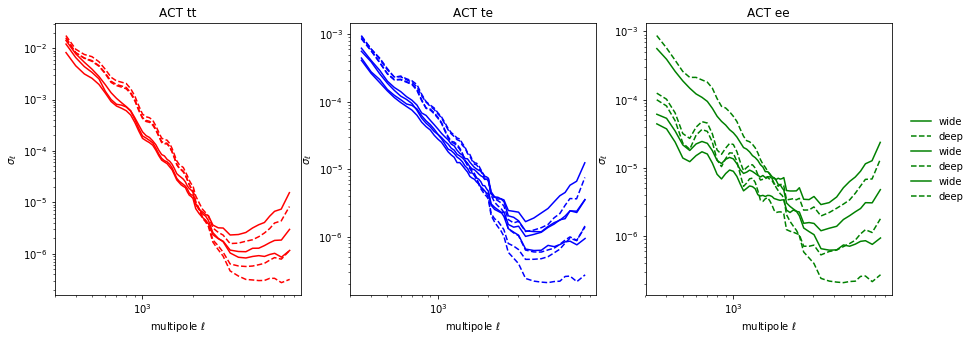

In [24]:
figure(figsize=(15,5))
col={'tt':'r','te':'b','ee':'g'}
nb = {'tt':3,'te':4,'ee':3}
t0 = 0
for i,lbl in enumerate(nb.keys()):
    subplot( 1,3,i+1)
    for it in range(nb[lbl]):
        plot( ell1[t0+it*nbin:t0+(it+1)*nbin], sqrt(var1)[t0+it*nbin:t0+(it+1)*nbin], color=col[lbl], label=f"wide")
        plot( ell2[t0+it*nbin:t0+(it+1)*nbin], sqrt(var2)[t0+it*nbin:t0+(it+1)*nbin], ls='--', color=col[lbl], label=f"deep")
    t0 += t*nbin
    loglog()
    ylabel( "$\\sigma_\ell$")
    xlabel( "multipole $\ell$")
    title( f"ACT {lbl}")
legend(bbox_to_anchor=(1.04,0.5), loc="center left")

In [35]:
binning = fits.getdata( f"{PKdir}/planck_2020/hillipop/data/binning_ext.fits")[[0,1,3,9,10,14]]
var3 = 1e24/diag(fits.getdata( f"{PKdir}/planck_2020/hillipop/data/invfll_NPIPE_detset_ext_TT.fits"))

/pbs/home/m/mtristra/.local/lib/python3.6/site-packages/ipykernel_launcher.py:15: RuntimeWarning: divide by zero encountered in true_divide
  from ipykernel import kernelapp as app
/pbs/home/m/mtristra/.local/lib/python3.6/site-packages/ipykernel_launcher.py:18: RuntimeWarning: divide by zero encountered in true_divide


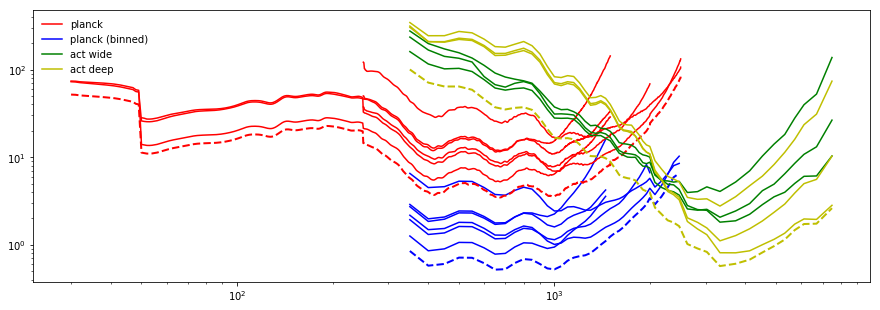

In [36]:
figure(figsize=(15,5))
l = array(ell1)[:52]

t0=0
sig3 = np.zeros( (6,7926) )
for t in range(len(binning)):
    ell = arange( binning[t][0], binning[t][1]+1)
    sig3[t][ell] = sqrt(var3[t0:t0+len(ell)])
    plot( ell, sig3[t][ell], 'r', label='planck' if t==0 else None)
    ra = array(l<=binning[t][1])
    plot( l[ra], array(sqrt(bwf1[:52]**2@(sig3[t][2:]**2)))[ra], 'b', label='planck (binned)' if t==0 else None)
    t0 += len(ell)

sig3[sig3 == 0.] = np.inf
plot( 1./sqrt(sum(1./sig3**2,0)), 'r--', lw=2)

ra = array(l<=2500)
sig4 = 1./sqrt(sum(1./sig3**2,0))
sig4[sig4 == inf] = 0.
plot( l[ra], array(sqrt(bwf1[:52]**2@(sig4[2:]**2)))[ra], 'b--', lw=2)

sig1 = sqrt(var1[:3*nbin].reshape(-1,nbin))
sig2 = sqrt(var2[:3*nbin].reshape(-1,nbin))
for i,s in enumerate(sig1): plot( l, l*(l+1)/2/pi*s, 'g', label='act wide' if not i else None)
for i,s in enumerate(sig2): plot( l, l*(l+1)/2/pi*s, 'y', label='act deep' if not i else None)
plot( l, l*(l+1)/2/pi/sqrt(sum(1./sig1**2+1./sig2**2,0)), 'y--', lw=2)

loglog()
legend()